In [1]:
import pandas as pd

red_url = "https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/winequality-red.csv"
white_url = "https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/winequality-white.csv"

red_wine = pd.read_csv(red_url, sep=";")
white_wine = pd.read_csv(white_url, sep=";")

red_wine['color'] = 1.0
white_wine['color'] = 0.

wine = pd.concat([red_wine, white_wine])

x = wine.drop(["color"], axis=1)
y = wine['color']

wine['taste'] = [1. if grade>5 else 0. for grade in wine['quality']]

x = wine.drop(['taste','quality'], axis=1)
y = wine['taste']

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=13)

wine_tree = DecisionTreeClassifier(max_depth=2, random_state=13)
wine_tree.fit(x_train,y_train)

y_pred_tr = wine_tree.predict(x_train)
y_pred_test = wine_tree.predict(x_test)

print('Train ACC: ', accuracy_score(y_train, y_pred_tr))
print('Test ACC: ', accuracy_score(y_test, y_pred_test))

Train ACC:  0.7294593034442948
Test ACC:  0.7161538461538461


In [4]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

print('accuracy: ', accuracy_score(y_test, y_pred_test))
print('Recall: ', recall_score(y_test, y_pred_test))
print('precision: ', precision_score(y_test, y_pred_test))
print('auc score: ', roc_auc_score(y_test, y_pred_test))
print('f1 score: ', f1_score(y_test, y_pred_test))

accuracy:  0.7161538461538461
Recall:  0.7314702308626975
precision:  0.8026666666666666
auc score:  0.7105988470875331
f1 score:  0.7654164017800381


In [7]:
import matplotlib.pyplot as plt

pred_prob = wine_tree.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, pred_prob)

In [9]:
fpr

array([0.        , 0.14884696, 0.25366876, 0.31027254, 1.        ])

In [11]:
tpr

array([0.        , 0.45078979, 0.65492102, 0.73147023, 1.        ])

In [15]:
thresholds

array([       inf, 0.87802198, 0.72692794, 0.67447307, 0.38397406])

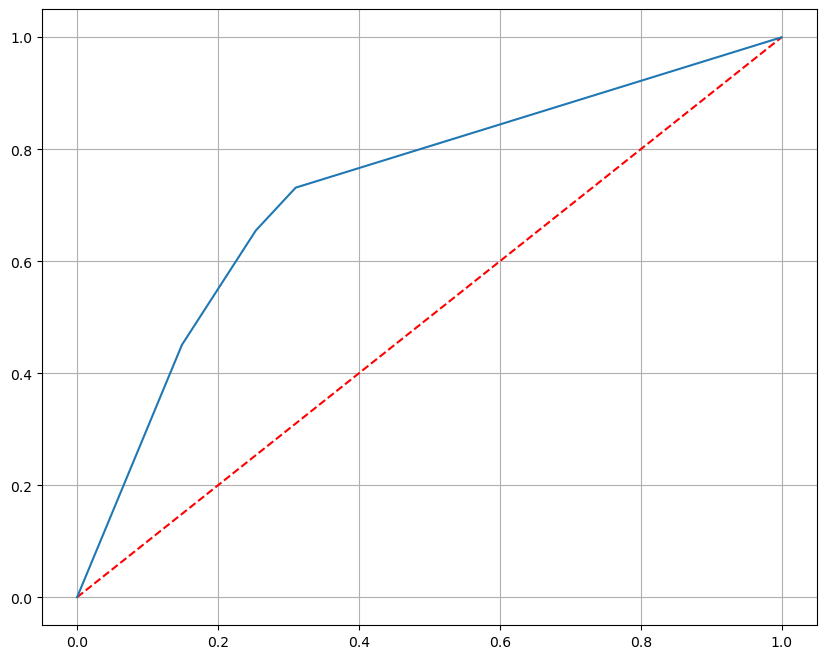

In [19]:
plt.figure(figsize=(10,8))
plt.plot([0,1],[0,1], 'r', ls="dashed")
plt.plot(fpr,tpr)
plt.grid()
plt.show()